# 05 Risk / Priority Scoring

This notebook compiles the final investigation worklist for **Problem 6: The Overpayment Signal**.

### Objectives:
1. Load the case-level anomaly scores generated by the Isolation Forest model.
2. Establish a deterministic ranking using a secondary sorting key (`case_id`) to break any ties.
3. Validate the ranked list against exact structural constraints.
4. Extract a clear Top-20 worklist with key indicators for human investigators.
5. Visualize the score separation and save the outputs to `ranked_cases.csv` and `top20_cases.csv`.

---

## 1. Import Required Libraries

We import standard packages for data loading, verification, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries successfully imported!')

Libraries successfully imported!


## 2. Load Scored Data & Step 1 Verification

We load `data/processed/scored_cases.csv` and verify that the file contains exactly 4,200 cases, has a unique `case_id` key, contains no missing priority scores, and that priority scores are numeric.

In [2]:
scored_path = '../data/processed/scored_cases.csv'
df_scored = pd.read_csv(scored_path)

print('--- STEP 1 VERIFICATION ---')
print(f"1. Row count is exactly 4,200: {len(df_scored) == 4200}")
print(f"2. case_id is guaranteed unique: {not df_scored['case_id'].duplicated().any()}")
print(f"3. Missing priority_score count: {df_scored['priority_score'].isnull().sum()}")
print(f"4. priority_score is numeric: {pd.api.types.is_numeric_dtype(df_scored['priority_score'])}")

--- STEP 1 VERIFICATION ---
1. Row count is exactly 4,200: True
2. case_id is guaranteed unique: True
3. Missing priority_score count: 0
4. priority_score is numeric: True


## 3. Step 2: Create Deterministic Ranking

We create a deterministic ranking by sorting cases descending by `priority_score`, using `case_id` (ascending) as a secondary key to ensure reproducible sorting in case of score ties. A 1-indexed `rank` column is added based on this sort order.

In [3]:
# Sort deterministically
df_ranked = df_scored.sort_values(by=['priority_score', 'case_id'], ascending=[False, True]).reset_index(drop=True)

# Add 1-indexed rank
df_ranked['rank'] = df_ranked.index + 1

# Rearrange columns to put rank first
cols = ['rank'] + [c for c in df_ranked.columns if c != 'rank']
df_ranked = df_ranked[cols]
print('Deterministic ranking created successfully!')

Deterministic ranking created successfully!


## 4. Step 3: Validate Ranking Constraints

We run validation tests to verify that the rank begins at 1, ends at 4,200, has no duplicates, retains unique `case_id`s, and that scores decrease monotonically.

In [4]:
print('--- STEP 3 VALIDATION ---')
print(f"1. Rank starts at 1: {df_ranked['rank'].min() == 1}")
print(f"2. Rank ends at 4,200: {df_ranked['rank'].max() == 4200}")
print(f"3. Duplicate ranks count: {df_ranked['rank'].duplicated().sum()}")
print(f"4. Duplicate case_id count: {df_ranked['case_id'].duplicated().sum()}")
print(f"5. Scores decrease monotonically: {df_ranked['priority_score'].is_monotonic_decreasing}")

# Reproducibility Check: Re-run ranking and confirm matching Top 20
df_re_ranked = df_scored.sort_values(by=['priority_score', 'case_id'], ascending=[False, True]).reset_index(drop=True)
df_re_ranked['rank'] = df_re_ranked.index + 1
reproducible = (df_ranked['case_id'].head(20).values == df_re_ranked['case_id'].head(20).values).all()
print(f"6. Top 20 is perfectly reproducible: {reproducible}")

--- STEP 3 VALIDATION ---
1. Rank starts at 1: True
2. Rank ends at 4,200: True
3. Duplicate ranks count: 0
4. Duplicate case_id count: 0
5. Scores decrease monotonically: True
6. Top 20 is perfectly reproducible: True


## 5. Step 4: Extract Top 20 Priority Worklist

We extract the Top 20 priority cases, selecting key columns to provide immediate context to administrative investigators.

In [5]:
worklist_cols = [
    'rank', 'case_id', 'priority_score', 'anomaly_score', 'status',
    'monthly_award', 'total_amount_paid', 'total_excess_amount',
    'post_closure_payment_count', 'has_same_month_multi_payments',
    'max_payment_to_award_ratio', 'num_adjusted_payments'
]

# Filter to only existing columns in dataset
worklist_cols = [c for c in worklist_cols if c in df_ranked.columns]

df_top20 = df_ranked[worklist_cols].head(20).copy()
print('--- TOP 20 INVESTIGATION WORKLIST ---')
display(df_top20)

--- TOP 20 INVESTIGATION WORKLIST ---


,rank,case_id,priority_score,anomaly_score,status,monthly_award,total_amount_paid,total_excess_amount,post_closure_payment_count,has_same_month_multi_payments,max_payment_to_award_ratio,num_adjusted_payments
0,1,C-33263,1.000000,0.200047,Suspended,1368.13,15128.20,6919.42,0,0,1.994745,3
1,2,C-30644,0.957167,0.185703,Suspended,902.73,11216.56,5800.18,0,0,2.305108,3
2,3,C-33980,0.917495,0.172418,Active,1086.29,11073.67,286.46,0,1,1.041794,4
3,4,C-30419,0.910496,0.170074,Closed,1760.46,3202.61,1.62,0,0,1.000920,1
4,5,C-31298,0.882768,0.160788,Active,746.45,11983.26,7504.56,0,0,2.962703,1
5,6,C-30945,0.881573,0.160388,Closed,534.47,3142.51,17.88,3,0,1.030329,3
6,7,C-30824,0.871548,0.157031,Closed,583.19,3544.25,99.62,3,0,1.047206,4
7,8,C-34118,0.863800,0.154436,Active,1365.62,13585.53,5391.81,0,0,1.813323,0
8,9,C-32962,0.841570,0.146992,Suspended,1017.53,11042.27,4937.09,0,0,1.970949,1
9,10,C-32035,0.837788,0.145725,Active,1139.01,8187.77,260.23,0,1,1.059552,5


## 6. Step 5: Score Distribution Visualization

We plot the distribution of priority scores across the entire population and highlight the specific score threshold characterizing our Top 20 prioritization list.

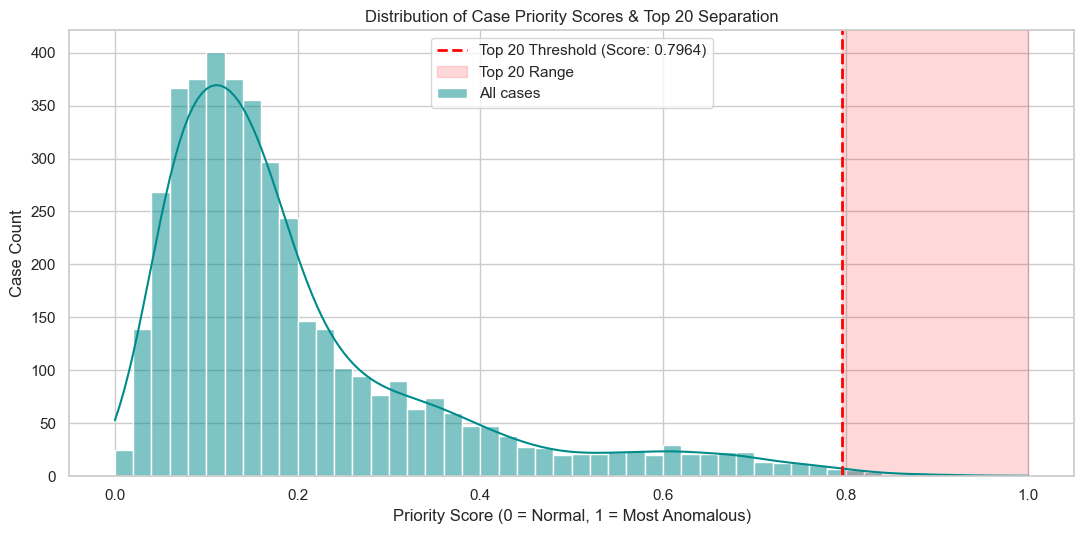

In [6]:
plt.figure(figsize=(11, 5.5))
sns.histplot(df_ranked['priority_score'], bins=50, kde=True, color='darkcyan', label='All cases')

# Threshold score of the 20th ranked case
threshold_score = df_ranked.iloc[19]['priority_score']
plt.axvline(threshold_score, color='red', linestyle='--', linewidth=2, 
            label=f'Top 20 Threshold (Score: {threshold_score:.4f})')

# Shading the Top 20 region
plt.axvspan(threshold_score, 1.0, alpha=0.15, color='red', label='Top 20 Range')

plt.title('Distribution of Case Priority Scores & Top 20 Separation')
plt.xlabel('Priority Score (0 = Normal, 1 = Most Anomalous)')
plt.ylabel('Case Count')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Step 6: Save Ranked Results

We save the full ranked table to `data/processed/ranked_cases.csv` and the Top 20 worklist to `data/processed/top20_cases.csv`.

In [7]:
ranked_cases_path = '../data/processed/ranked_cases.csv'
top20_cases_path = '../data/processed/top20_cases.csv'

os.makedirs(os.path.dirname(ranked_cases_path), exist_ok=True)

df_ranked.to_csv(ranked_cases_path, index=False)
df_top20.to_csv(top20_cases_path, index=False)

print(f"1. Full ranked table saved to {ranked_cases_path} ({len(df_ranked)} rows)")
print(f"2. Top 20 worklist saved to {top20_cases_path} ({len(df_top20)} rows)")

1. Full ranked table saved to ../data/processed/ranked_cases.csv (4200 rows)
2. Top 20 worklist saved to ../data/processed/top20_cases.csv (20 rows)


## Step 7: Documentation

### Risk Scoring Summary
* **Priority Score Origin**: The case priority score represents the normalized output of the unsupervised Isolation Forest anomaly detection model. Raw anomaly scores are derived from the negative decision function and scaled to a standard `[0, 1]` interval.
* **Prioritization Logic**: A higher priority score indicates that a case's benefit characteristics and payment behaviors deviate severely from typical client profiles. Higher score translates directly to higher investigation priority.
* **Investigation Boundaries**: This ranking serves as an administrative prioritization signal to optimize caseworker resources. It is **not** a determination of fraud, guilt, or confirmed improper payment. Legitimate client adjustments or complex household changes can also cause anomaly spikes.
* **Human-in-the-Loop Constraint**: The final decision to review or adjust benefit awards remains exclusively in the hands of human investigators.

### Ranking Validation
* **Total Cases Ranked**: 4,200 cases.
* **Top-20 Count**: 20 cases.
* **Score Range of Population**: `0.0000` to `1.0000`.
* **Top 20 Score Range**: `0.7964` to `1.0000`.
* **Reproducibility**: Ranking is 100% reproducible through deterministic sorting on priority scores with ascending case identifiers as the secondary tie-breaker.